<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# III. Materiais elásticos
## Lei de Hooke. Parte I
## Problema 1 <a name="PIII61"></a>

Num ponto $P$ da superfície de um corpo está colada a roseta de extensómetros a 45º indicada na Figura, cujas leituras são $\varepsilon_1 = 2 \times 10^{-6}$ , $\varepsilon_2 = 1 \times 10^{-6}$ e $\varepsilon_3 = -4 \times 10^{-6}$, respectivamente nos elementos 1, 2 e 3. Calcule as tensões principais e as direções principais no ponto $P$, sabendo que o material do corpo apresenta as seguintes caraterísticas : $E = 200$ GPa e $\nu$ = 0,3. (nota: assuma um estado plano de tensão aplicado ao corpo).

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au06/Au06_P001_i1.jpg"
width="300" height="240">



## Resolução

### Algoritmo de resolução

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au06/Au06_P001_i2.jpg" width="600">

A extensão linear numa determinada direção definida pelo ângulo $\alpha$ com a direção horizontal do eixo dos $xx$ é
dada por:

\begin{equation*}
\begin{aligned}
\varepsilon_{\alpha} &= \varepsilon_{xx}\cos^2\alpha +
\varepsilon_{yy}\sin^2\alpha + \gamma_{xy}\sin\alpha\cos\alpha \\
\end{aligned}
\end{equation*}

As equações de transformação associadas a uma roseta de três elementos podem ser agrupadas no seguinte sistema de equações:

\begin{equation*}
\begin{cases}
\varepsilon_\mathrm{1} \equiv \varepsilon (\alpha=0^\circ) & =
\varepsilon_{xx}\cos^2\alpha_1 + \varepsilon_{yy}\sin^2\alpha_1 +
\gamma_{xy}\sin\alpha_1\cos\alpha_1 \\
\varepsilon_\mathrm{2} \equiv \varepsilon (\alpha=+45^\circ) & =
\varepsilon_{xx}\cos^2\alpha_2 + \varepsilon_{yy}\sin^2\alpha_2 +
\gamma_{xy}\sin\alpha_2\cos\alpha_2 \\
\varepsilon_\mathrm{3} \equiv \varepsilon (\alpha=90^\circ) & =
\varepsilon_{xx}\cos^2\alpha_3 + \varepsilon_{yy}\sin^2\alpha_3 +
\gamma_{xy}\sin\alpha_3\cos\alpha_3
\end{cases}
\end{equation*}

Para a roseta a 45$^\circ$, o seguinte sistema matricial pode ser diretamente obtido:

\begin{equation*}
\begin{bmatrix}
1 & 0 & 0 \\
1/2 & 1/2 & 1/2 \\
0 & 1 & 0
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{xx} \\
\varepsilon_{yy} \\
\gamma_{xy}
\end{bmatrix}=
\begin{bmatrix}
\varepsilon_{0^\circ} \\
\varepsilon_{45^\circ} \\
\varepsilon_{90^\circ}
\end{bmatrix}
\end{equation*}

Pelo que, para a roseta a 45$^\circ$, obtem-se simplificadamente o sistema de equações:

\begin{equation*}
\begin{cases}
\varepsilon_1{(\alpha=0^\circ)} \equiv \varepsilon_{0^\circ} &=& \varepsilon_{xx} \\
\varepsilon_2{(\alpha=+45^\circ)} \equiv \varepsilon_{+45^\circ} &=& (\varepsilon_{xx} +
\varepsilon_{yy} + \gamma_{xy})/2 \\
\varepsilon_3{(\alpha=90^\circ)} \equiv \varepsilon_{90^\circ} &=& \varepsilon_{yy} \\
\end{cases}
\end{equation*}

Pelo que o estado de deformação pode ser obtido à custa de $\varepsilon_i~(i=1,2,3)$ pelas seguintes expressões:

\begin{equation*}
\begin{cases}
\varepsilon_{xx}  &=&  \varepsilon_{0^\circ}\\
\varepsilon_{yy}  &=&  \varepsilon_{90^\circ}\\
\gamma_{xy} &=& 2\varepsilon_{+45^\circ} - (\varepsilon_{0^\circ} + \varepsilon_{90^\circ})\\
\end{cases}
\end{equation*}

Este resultado pode ser confirmado usando o círculo de Mohr como ilustrado:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au06/Au06_P001_i3.jpg"
width="700" height="340">

In [21]:
import numpy as np
from sympy.solvers import solve
from sympy import symbols
import matplotlib.pyplot as plt

# versão 1:
print('------------------------------')
print('Versão 1:')
print('------------------------------')

exx,eyy,gxy,t = symbols('exx eyy gxy t')

# unit: degree, strains = 10^(-6) micro-strains
eps1 = 2.*1e-6; ang1 = 0. # extensómetro 1
eps2 = 1.*1e-6; ang2 = 45. # extensómetro 2
eps3 = -4.*1e-6; ang3 = 90. # extensómetro 3

def extens(exx,eyy,gxy,t): return exx*np.cos(t)**2 + eyy*np.sin(t)**2 + gxy*np.sin(t)*np.cos(t)

eq1 = eps1 - extens(exx,eyy,gxy,np.deg2rad(ang1))
eq2 = eps2 - extens(exx,eyy,gxy,np.deg2rad(ang2))
eq3 = eps3 - extens(exx,eyy,gxy,np.deg2rad(ang3))
defs = solve({eq1,eq2,eq3},[exx,eyy,gxy])
exxP  = float(defs[exx])
eyyP  = float(defs[eyy])
gxyP  = float(defs[gxy])
exyP  = gxyP/2
print(f'exxP (sistema equações) = {exxP:.2e}')
print(f'eyyP (sistema equações) = {eyyP:.2e}')
print(f'gxyP (sistema equações) = {gxyP:.2e}')
print(f'          exyP (gxyP\\2) = {exyP:.2e}')

------------------------------
Versão 1:
------------------------------
exxP (sistema equações) = 2.00e-06
eyyP (sistema equações) = -4.00e-06
gxyP (sistema equações) = 4.00e-06
          exyP (gxyP\2) = 2.00e-06


In [22]:
# versão 2:
print('------------------------------')
print('Versão 2:')
print('------------------------------')

def CoefMat3roset(t1,t2,t3):
    return np.array([[np.cos(t1)**2, np.sin(t1)**2, np.cos(t1)*np.sin(t1)],
                     [np.cos(t2)**2, np.sin(t2)**2, np.cos(t2)*np.sin(t2)],
                     [np.cos(t3)**2, np.sin(t3)**2, np.cos(t3)*np.sin(t3)]])

ang1 = np.deg2rad(0)
ang2 = np.deg2rad(45)
ang3 = np.deg2rad(90)
ext3r = np.array([eps1,eps2,eps3])
estadodef2 = np.dot(np.linalg.inv(CoefMat3roset(ang1,ang2,ang3)),ext3r)
print(f'exxP (formulação matricial) = {estadodef2[0]:.2e}')
print(f'eyyP (formulação matricial) = {estadodef2[1]:.2e}')
print(f'gxyP (formulação matricial) = {estadodef2[2]:.2e}')


------------------------------
Versão 2:
------------------------------
exxP (formulação matricial) = 2.00e-06
eyyP (formulação matricial) = -4.00e-06
gxyP (formulação matricial) = 4.00e-06


In [23]:

# versão 3:
print('------------------------------')
print('Versão 3:')
print('------------------------------')

exxPv2 = eps1
eyyPv2 = eps3
gxyPv2 = 2*eps2 - (eps1 + eps3)
print(f'exxP (explicitamente) = {exxPv2:.2e}')
print(f'eyyP (explicitamente) = {eyyPv2:.2e}')
print(f'gxyP (explicitamente) = {gxyPv2:.2e}')

------------------------------
Versão 3:
------------------------------
exxP (explicitamente) = 2.00e-06
eyyP (explicitamente) = -4.00e-06
gxyP (explicitamente) = 4.00e-06


Matriz das deformações no ponto $P$:

\begin{equation*}
\underline{\underline{D}} \equiv [D] \equiv D_{ij} =
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz} \\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{zy}/2 & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
2 & 2 & 0 \\
2 & -4 & 0 \\
0 & 0 & \varepsilon_{zz}
\end{bmatrix} \times 10^{-6}
\end{equation*}

##### Da lei de Hooke para um material isotrópico.

Para um material isotrópico a lei de Hooke geral vem expressa pela seguinte relação (notação indicial):

\begin{equation*}
\varepsilon_{ij} = \frac{1}{E}[(1+\nu)\sigma_{ij} - \nu\delta_{ij}\sigma_{kk}]
\end{equation*}

ou inversamente,

\begin{equation*}
\sigma_{ij} = \frac{E}{1+\nu}\varepsilon_{ij} + \frac{\nu E}{(1+\nu)(1-2\nu)}\varepsilon_{kk}\delta_{ij}
\end{equation*}


Em forma matricial a lei constitutiva linear elástica expressa em termos de módulo de Young ($E$) e coeficiente de Poisson ($\nu$) vem:

\begin{equation*}
\begin{cases}
\varepsilon_{11} &= \frac{1}{E}[\sigma_{11} - \nu(\sigma_{22}+\sigma_{33})] \\
\varepsilon_{22} &= \frac{1}{E}[\sigma_{22} - \nu(\sigma_{11}+\sigma_{33})] \\
\varepsilon_{33} &= \frac{1}{E}[\sigma_{33} - \nu(\sigma_{11}+\sigma_{22})] \\
2\varepsilon_{23} &= \gamma_{23} = \frac{\tau_{23}}{G}\\
2\varepsilon_{13} &= \gamma_{13} = \frac{\tau_{13}}{G}\\
2\varepsilon_{12} &= \gamma_{12} = \frac{\tau_{12}}{G}\\
\end{cases}
\end{equation*}

com,

\begin{equation*}
G = \frac{E}{2(1+\nu)}
\end{equation*}

Na forma matricial têm-se:

\begin{equation*}
\begin{bmatrix}
\varepsilon_{11} \\ \varepsilon_{22} \\ \varepsilon_{33} \\ 2\varepsilon_{23} \\ 2\varepsilon_{13} \\ 2\varepsilon_{12}
\end{bmatrix} \equiv
\begin{bmatrix}
\varepsilon_{11} \\ \varepsilon_{22} \\ \varepsilon_{33} \\
\gamma_{23} \\ \gamma_{13} \\ \gamma_{12}
\end{bmatrix} = \frac{1}{E}
\begin{bmatrix}
1 & -\nu & -\nu & 0 & 0 & 0 \\
-\nu & 1 & -\nu & 0 & 0 & 0 \\
-\nu & -\nu & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 2(1+\nu) & 0 & 0 \\
0 & 0 & 0 & 0 & 2(1+\nu) & 0 \\
0 & 0 & 0 & 0 & 0 & 2(1+\nu) \\
\end{bmatrix}
\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \sigma_{33} \\ \tau_{23} \\  \tau_{13} \\ \tau_{12}
\end{bmatrix}
\end{equation*}

ou pela relação inversa,

\begin{equation*}
\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \sigma_{33} \\ \tau_{23} \\  \tau_{13} \\ \tau_{12}
\end{bmatrix} = \frac{E}{(1+\nu)(1-2\nu)}
\begin{bmatrix}
1-\nu & \nu & \nu & 0 & 0 & 0 \\
\nu & 1-\nu & \nu & 0 & 0 & 0 \\
\nu & \nu & 1-\nu & 0 & 0 & 0 \\
0 & 0 & 0 & (1-2\nu)/2 & 0 & 0 \\
0 & 0 & 0 & 0 & (1-2\nu)/2 & 0 \\
0 & 0 & 0 & 0 & 0 & (1-2\nu)/2 \\
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{11} \\ \varepsilon_{22} \\ \varepsilon_{33} \\ 2\varepsilon_{23} \\ 2\varepsilon_{13} \\ 2\varepsilon_{12}
\end{bmatrix}
\end{equation*}


Para um estado plano de tensão, no plano $1-2$, para o qual se verifica: $\sigma_{33} = \tau_{31} = \tau_{32} = 0$, a lei de Hooke escreve-se:

\begin{equation*}
\begin{cases}
\varepsilon_{11} &= \frac{1}{E}[\sigma_{11} - \nu(\sigma_{22})] \\
\varepsilon_{22} &= \frac{1}{E}[\sigma_{22} - \nu(\sigma_{11})] \\
\gamma_{12} &=  \frac{\tau_{12}}{G}\\
\end{cases}
\quad\wedge\quad
\begin{cases}
\sigma_{11} &= \frac{E}{(1-\nu^2)}(\varepsilon_{11} + \nu\varepsilon_{22}) \\
\sigma_{22} &= \frac{E}{(1-\nu^2)}(\nu\varepsilon_{11} +
\varepsilon_{22}) \\
\tau_{12} &= G\gamma_{12} = \frac{E}{2(1+\nu)}\gamma_{12} = \frac{E}{1+\nu}\varepsilon_{12}\\
\end{cases}
\end{equation*}

com,

\begin{equation*}
\varepsilon_{33} = -\frac{\nu}{E}(\sigma_{11}+\sigma_{22}) \\
\end{equation*}

A segunda lei de termodinâmica requer que as constantes elásticas verifiquem os seguintes limites:

\begin{equation*}
\begin{aligned}
E,~G > 0 \\
-1 < \nu < \frac{1}{2}
\end{aligned}
\end{equation*}

In [24]:
np.set_printoptions(precision=0)
E = 200*1e3 # unit: MPa
v = 0.3
G = E/2/(1+v)
print('Propriedades do material: ---------------')
print('     E (MPa) = ',E)
print('           v = ',v)
print(f'     G (MPa) = {G:.2f}')

# Versão 1
print('=====================================================')
print('Versão 1:')
print('=====================================================')
e11,e22,e33,e23,e13,e12 = symbols('e11 e22 e33 e23 e13 e12')
s11,s22,s12 = symbols('s11 s22 s12')

# estado plano de tensão
szz = 0 ; sxz = 0; syz = 0

def e11(sxx,syy,szz,E): return (sxx - v*(syy+szz))/E
def e22(sxx,syy,szz,E): return (syy - v*(sxx+szz))/E
def e33(sxx,syy,szz,E): return (szz - v*(sxx+syy))/E
def e23(syz,G): return (syz/G)/2
def e13(sxz,G): return (sxz/G)/2
def e12(sxy,G): return (sxy/G)/2

ex1 = exxP - e11(s11,s22,szz,E)
ex2 = eyyP - e22(s11,s22,szz,E)
ex6 = gxyP/2 - e12(s12,G)

tens1 = solve({ex1,ex2},{s11,s22})
sxxP = float(tens1[s11])
print(f'Sxx(P) [MPa] = {sxxP:.6f}')
syyP = float(tens1[s22])
print(f'Syy(P) [MPa] = {syyP:.6f}')

tens2 = solve({ex6},{s12})
sxyP = float(tens2[s12])
print(f'Sxy(P) [MPa] = {sxyP:.6f}')

ezzP = -(v/E)*(sxxP + syyP)
print(f'Ezz(P) = {ezzP:.4e} :: {ezzP*1e6:.2f} micro def')

Propriedades do material: ---------------
     E (MPa) =  200000.0
           v =  0.3
     G (MPa) = 76923.08
Versão 1:
Sxx(P) [MPa] = 0.175824
Syy(P) [MPa] = -0.747253
Sxy(P) [MPa] = 0.307692
Ezz(P) = 8.5714e-07 :: 0.86 micro def


In [25]:

# Versão 2
print('=====================================================')
print('Versão 2:')
print('=====================================================')
SxxPv2 = E/(1-v**2)*(exxP + v*eyyP)
print(f'Sxx(P) [MPa] = {SxxPv2:.6f}')
SyyPv2 = E/(1-v**2)*(v*exxP + eyyP)
print(f'Syy(P) [MPa] = {SyyPv2:.6f}')
SxyPv2 = G*gxyP
print(f'Sxy(P) [MPa] = {SxyPv2:.6f}')

Versão 2:
Sxx(P) [MPa] = 0.175824
Syy(P) [MPa] = -0.747253
Sxy(P) [MPa] = 0.307692


Matriz das tensões:

\begin{equation*}
\underline{\underline{\sigma}} = [\sigma] = \sigma_{ij} =
\begin{bmatrix}
0.175824 & 0.307692 & 0 \\
0.307692 & -0.747252 & 0 \\
0 & 0 & 0
\end{bmatrix}~\textrm{[MPa]}
\end{equation*}

Este estado de tensão corresponde a um estado de tensão plano. $\sigma_{zz} = 0$ MPa é uma tensão principal e $\vec{k}$ é um vetor principal.

matriz das tensões : 
 [[ 0.17582  0.30769  0.     ]
 [ 0.30769 -0.74725  0.     ]
 [ 0.       0.       0.     ]]  [MPa]

PLANO x-y:

Tensões (normais) principais: -------------------------------------------
angPrincipal (deg) = 16.845
tens. xx plano principal [1] (MPa) = 0.268986
tens. yy plano principal [1] (MPa) = -0.840414
tens. xy plano principal [1] (MPa) = 0.000000

angPrincipal 2 (deg) = 106.85
tens xx plano principal [2] (MPa) = -0.84
tens yy plano principal [2] (MPa) = 0.27
tens xy plano principal [2] (MPa) = -0.00
ângulo de corte principal (deg) = 61.845
tens. corte máxima (MPa) = -0.554700

Tensões de corte maximas\mínima: -------------------------------------------
Ângulo tensão corte max (Deg) = -28.15
tens xx - plano  tensão de corte max (MPa) = -0.29
tens yy - plano  tensão de corte max (MPa) = -0.29
tens xy - plano  tensão de corte max (MPa) = 0.55
Ângulo tensão corte min (Deg) = 61.85
tens xx - plano  tensão de corte min (MPa) = -0.29
tens yy - plano  tensão de corte 

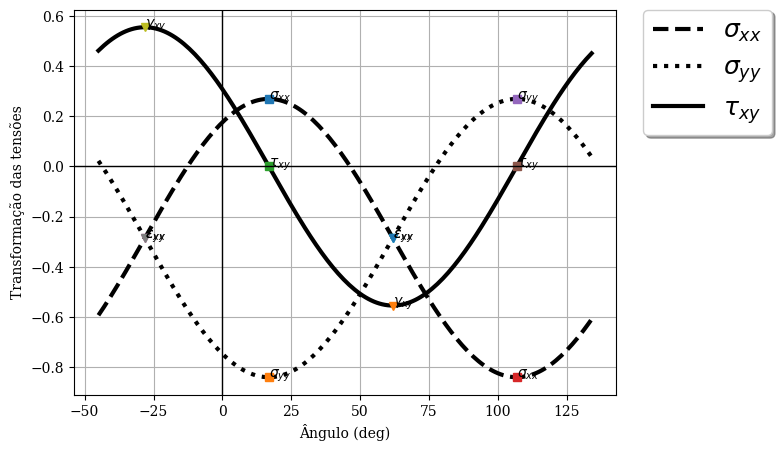

In [26]:
np.set_printoptions(precision=5)

def mtensoes(sXX,sXY,sXZ,sYY,sYZ,sZZ): return np.array([[sXX,sXY,sXZ],[sXY,sYY,sYZ],[sYZ,sYZ,sZZ]])

tt0 = mtensoes(sxxP,sxyP,0,syyP,0,0)
print('matriz das tensões : \n',tt0,' [MPa]')

def sxx1(sxx,syy,txy,t):
    return (sxx+syy)/2 + (sxx-syy)/2*np.cos(2*t) + txy*np.sin(2*t)

def syy1(sxx,syy,txy,t):
    return (sxx+syy)/2 - (sxx-syy)/2*np.cos(2*t) - txy*np.sin(2*t)

def txy1(sxx,syy,txy,t):
    return (syy-sxx)/2*np.sin(2*t) + txy*np.cos(2*t)

def angPrincipal(sxx,syy,txy):
    return np.arctan(2*txy/(sxx-syy))/2

def angShearMax(sxx,syy,sxy): return np.arctan(- (sxx-syy)/2/sxy )/2

def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

print('\nPLANO x-y:\n')
sxx = tt0[0,0]
syy = tt0[1,1]
txy = tt0[0,1]

angt = np.arange(-45,135,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

print('Tensões (normais) principais: -------------------------------------------')
aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal (deg) =','{:.3f}'.format(aprinc))
tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens. xx plano principal [1] (MPa) =','{:.6f}'.format(tsxx1))
print('tens. yy plano principal [1] (MPa) =','{:.6f}'.format(tsyy1))
print('tens. xy plano principal [1] (MPa) =','{:.6f}'.format(ttxy1))

aprinc2 = aprinc + 90
print('\nangPrincipal 2 (deg) =','{:.2f}'.format(aprinc2))
tsxx2 = sxx1(sxx,syy,txy,np.deg2rad(aprinc2))
tsyy2 = syy1(sxx,syy,txy,np.deg2rad(aprinc2))
ttxy2 = txy1(sxx,syy,txy,np.deg2rad(aprinc2))
print('tens xx plano principal [2] (MPa) =','{:.2f}'.format(tsxx2))
print('tens yy plano principal [2] (MPa) =','{:.2f}'.format(tsyy2))
print('tens xy plano principal [2] (MPa) =','{:.2f}'.format(ttxy2))

corteAngP1 = np.rad2deg(angShearMax(sxx,syy,txy)) + 90
tcortemax = txy1(sxx,syy,txy,np.deg2rad(corteAngP1))
print('ângulo de corte principal (deg) =','{:.3f}'.format(corteAngP1))
print('tens. corte máxima (MPa) =','{:.6f}'.format(tcortemax))

print('\nTensões de corte maximas\\mínima: -------------------------------------------')
aS1 = angS(sxx,syy,txy)/2 # ângulo no espaço físico, radianos
print('Ângulo tensão corte max (Deg) =','{:.2f}'.format(np.rad2deg(aS1)))
tcortexxMa = sxx1(sxx,syy,txy,aS1)
tcorteyyMa = syy1(sxx,syy,txy,aS1)
tcortexyMa = txy1(sxx,syy,txy,aS1)
print('tens xx - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexxMa))
print('tens yy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcorteyyMa))
print('tens xy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexyMa))

aS2 = aS1 + np.pi/2
print('Ângulo tensão corte min (Deg) =','{:.2f}'.format(np.rad2deg(aS2)))
tcortexxMb = sxx1(sxx,syy,txy,aS2)
tcorteyyMb = syy1(sxx,syy,txy,aS2)
tcortexyMb = txy1(sxx,syy,txy,aS2)
print('tens xx - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexxMb))
print('tens yy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcorteyyMb))
print('tens xy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexyMb))


# use LaTeX fonts in the plot
#plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=3)
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$', linewidth=3)
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$', linewidth=3)
# points: principal stresses
ax.plot(aprinc, tsxx1, 's'), ax.text(aprinc, tsxx1,r'$\sigma_{xx}$')
ax.plot(aprinc, tsyy1, 's'), ax.text(aprinc, tsyy1,r'$\sigma_{yy}$')
ax.plot(aprinc, ttxy1, 's'), ax.text(aprinc, ttxy1,r'$\tau_{xy}$')
ax.plot(aprinc2, tsxx2, 's'), ax.text(aprinc2, tsxx2,r'$\sigma_{xx}$')
ax.plot(aprinc2, tsyy2, 's'), ax.text(aprinc2, tsyy2,r'$\sigma_{yy}$')
ax.plot(aprinc2, ttxy2, 's'), ax.text(aprinc2, ttxy2,r'$\tau_{xy}$')
# points: critical shear stresses
ax.plot(np.rad2deg(aS1), tcortexxMa, 'v')
ax.text(np.rad2deg(aS1), tcortexxMa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS1), tcorteyyMa, 'v')
ax.text(np.rad2deg(aS1), tcorteyyMa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS1), tcortexyMa, 'v')
ax.text(np.rad2deg(aS1), tcortexyMa,r'$\gamma_{xy}$')
ax.plot(np.rad2deg(aS2), tcortexxMb, 'v')
ax.text(np.rad2deg(aS2), tcortexxMb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS2), tcorteyyMb, 'v')
ax.text(np.rad2deg(aS2), tcorteyyMb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS2), tcortexyMb, 'v')
ax.text(np.rad2deg(aS2), tcortexyMb,r'$\gamma_{xy}$')

ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

#### Tensões principais

As tensões de corte são nulas em facetas que definem planos principais num dado ponto $P$ do corpo. Assim sendo, o vetor tensão que atua nesse ponto e segundo a normal exterior a essa faceta tem apenas uma componente normal:

\begin{equation*}
\vec{t}(P,\vec{n}) = t_x \vec{\imath} + t_y \vec{\jmath} + t_z \vec{k} = \sigma\,\vec{n}
\end{equation*}

em que $\sigma$ representa o módulo da tensão normal que atua na direção do versor $\vec{n}$. $\sigma$ é portanto uma tensão principal e a direção representada por $\vec{n}$ um eixo principal de tensão. As componentes do versor $\vec{n}$ no sistema de coordenadas $S(0,x,y,z)$ são dados pelos cosenos diretores:

\begin{array}{c|ccc}
& x & y & z \\\hline
n & l & m & n
\end{array}

pelo que: $\vec{n} = l \vec{\imath} + m \vec{\jmath} + n \vec{k}$. Desta forma, podem escrever-se as seguintes expressões escalares para as componentes cartesianas do vetor tensão $\vec{t}$:

\begin{equation*}
\begin{cases}
t_x = \sigma l \\
t_y = \sigma m \\
t_z = \sigma n \\
\end{cases}
\end{equation*}

Por outro lado, atendendo à fórmula de Cauchy:

\begin{equation*}
\vec{t}(P,\vec{n}) = \tilde{\sigma} \cdot \vec{n}~, \quad (\tilde{\sigma} = \tilde{\sigma}^T)
\end{equation*}

resulta a seguinte igualdade:

\begin{equation*}
\begin{aligned}
\tilde{\sigma} \cdot \vec{n} & = \sigma\,\vec{n} \\
(\sigma\tilde{I} - \tilde{\sigma})\cdot \vec{n} & = 0 \\
\end{aligned}
\end{equation*}

Este sistema tem as seguintes expressões escalares:

\begin{equation*}
\begin{cases}
l(\sigma-\sigma_{xx}) + m \tau_{xy} + n \tau_{xz} = 0 \\
l\tau_{xy} + m (\sigma-\sigma_{yy}) + n \tau_{yz} = 0 \\
l\tau_{xz} + m \tau_{yz} + n (\sigma-\sigma_{zz}) = 0
\end{cases}
\end{equation*}

A expressão anterior representa um sistema de equações lineares homogéneas na forma (notação indicial):

\begin{equation*}
\begin{aligned}
A_{ij} \cdot n_j & = 0~; \quad\textrm{com}\quad A_{ij} = \sigma\delta_{ij} - \sigma_{ij}\\
\end{aligned}
\end{equation*}

A solução trivial deste sistema de equações para o qual $n_j = 0$ ($l = m = n = 0$) não é possível porque $n_j\cdot n_j = 1$, ou seja, $l^2+m^2+n^2 = 1$. Surge da teoria da álgebra linear de sistemas de equações que a solução do sistema linear homogéneo só é possível se for nulo o determinante:

\begin{equation*}
\det(\sigma\delta_{ij} - \sigma_{ij})= 0
\end{equation*}

A solução desta expressão conduz a um polinómio cúbico caraterístico cujas raízes são os valores das três tensões principais.

In [27]:
np.set_printoptions(precision=5)
I1 = np.trace(tt0)
print('\n1º Invariante, I1:', '{:.6f}'.format(I1))

I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print('2º Invariante, I2 :', '{:.6f}'.format(I2))

I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.6f}'.format(I3))

valpropriosN = np.roots([1,-I1,I2,-I3])
print('\nNumpy : roots = ',valpropriosN)
valpropriosN = np.sort(valpropriosN)
sIII = valpropriosN[0]
sII = valpropriosN[1]
sI = valpropriosN[2]
print('\nTensão principal (valor próprio) sI ','{:.6f}'.format(sI),' [MPa]')
print('Tensão principal (valor próprio) sII ','{:.6f}'.format(sII),' [MPa]')
print('Tensão principal (valor próprio) sIII ','{:.6f}'.format(sIII),' [MPa]')


1º Invariante, I1: -0.571429
2º Invariante, I2 : -0.226060
3º Invariante, I3 : 0.000000

Numpy : roots =  [-0.84041  0.26899  0.     ]

Tensão principal (valor próprio) sI  0.268986  [MPa]
Tensão principal (valor próprio) sII  0.000000  [MPa]
Tensão principal (valor próprio) sIII  -0.840414  [MPa]


##### Círculo de Mohr

A análise do círculo de Mohr permite determinar os valores máximos e mínimos das componentes normais das tensões num determinado plano de análise. Para o plano $(0,x,y)$ vem:

\begin{equation*}
\sigma_{\textrm{max/min}} = \sigma_{\textrm{I/II}} = \sigma_{\textrm{médio}} + R
= \frac{\sigma_{xx} + \sigma_{yy}}{2} \pm
\sqrt{\left(\frac{\sigma_{xx}-\sigma_{yy}}{2}\right)^2+\tau_{xy}^2 }
\end{equation*}


PLANO x-y:

  Tensão normal mínima:  -0.840414
  Tensão normal máxima:  0.268986
   Tensão normal média:  -0.285714
Tensão de corte mínima:  -0.554700
Tensão de corte máxima:  0.554700


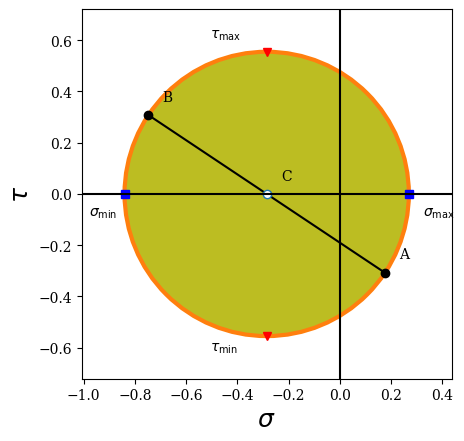

In [28]:
def mohr(S):
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print("  Tensão normal mínima: ", '{:.6f}'.format(Smin))
    print("  Tensão normal máxima: ", '{:.6f}'.format(Smax))
    print("   Tensão normal média: ", '{:.6f}'.format(center[0]))
    print("Tensão de corte mínima: ", '{:.6f}'.format(-radius))
    print("Tensão de corte máxima: ", '{:.6f}'.format(radius))

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [-S12, S12], 'ko')
    plt.plot([S11, S22], [-S12, S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(S11 + desv, -S12 + desv , 'A')
    plt.text(S22 + desv, S12 + desv, 'B')
    plt.text(Smin - 0.25*radius, -0.15*radius, r'$\sigma_\mathrm{min}$')
    plt.text(Smax + desv, -0.15*radius, r'$\sigma_\mathrm{max}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

    return Smin, Smax, center[0],radius,-radius

print('\nPLANO x-y:\n')
sxx = tt0[0,0]
syy = tt0[1,1]
sxy = tt0[0,1]
Tmin, Tmax, Tmed, Cmax, Cmin = mohr(np.array([[sxx, sxy],[sxy, syy]]))

#### Direções principais

As direções principais podem obter-se resolvendo um seguinte sistema de equações linearmente indepenentes obtidas de:

\begin{equation*}
(\sigma_{ij} - \sigma_\alpha\delta_{ij}) \cdot n_j = 0 \quad \wedge \quad n_i \cdot n_i = 1
\quad (\alpha = \mathrm{I,II,III})
\end{equation*}

In [29]:
d1,d2,d3 = symbols('d1 d2 d3')

def eq1(d1,d2,d3,vp): return (tt0[0,0] - vp)*d1 + tt0[0,1]*d2 + tt0[0,2]*d3
def eq2(d1,d2,d3,vp): return tt0[1,0]*d1 + (tt0[1,1] - vp)*d2 + tt0[1,2]*d3
def eq3(d1,d2,d3,vp): return tt0[2,0]*d1 + tt0[2,1]*d2 + (tt0[2,2] - vp)*d3
def eq4(d1,d2,d3): return d1**2 + d2**2 + d3**2 - 1

def versor(e1,e2,e3): return np.array([e1,e2,e3])

# 1 valor proprio -------------------
print('\nVetor próprio associado a sI = ','{:.2f}'.format(sI),'.............................')
print('\n(i) sistema de quações:')
E1_sI = eq1(d1,d2,d3,sI); print(E1_sI,' = 0')
E2_sI = eq2(d1,d2,d3,sI); print(E2_sI,' = 0')
E3_sI = eq3(d1,d2,d3,sI); print(E3_sI,' = 0')
E4_sI = eq4(d1,d2,d3); print(E4_sI,' = 0')
VetProp1 = solve([E1_sI,E3_sI,E4_sI], [d1,d2,d3], dict=True)
l1 = float(VetProp1[1][d1])
m1 = float(VetProp1[1][d2])
n1 = float(VetProp1[1][d3])
versorI = versor(l1,m1,n1)
print('\n (ii) nI = ','{:.3f}'.format(l1),'e1 +','{:.3f}'.format(m1),'e2 +','{:.3f}'.format(n1),'e3')



Vetor próprio associado a sI =  0.27 .............................

(i) sistema de quações:
-0.0931617346867677*d1 + 0.307692307692308*d2  = 0
0.307692307692308*d1 - 1.01623865776369*d2  = 0
-0.268985910510944*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nI =  0.957 e1 + 0.290 e2 + 0.000 e3


In [30]:

# 2 valor proprio -------------------
print('\nVetor próprio associado a sII= ','{:.2f}'.format(sII),' .............................')
print('\n (i) sistema de quações:')
E1_sII = eq1(d1,d2,d3,sII); print(E1_sII,' = 0')
E2_sII = eq2(d1,d2,d3,sII); print(E2_sII,' = 0')
E3_sII = eq3(d1,d2,d3,sII); print(E3_sII,' = 0')
E4_sII = eq4(d1,d2,d3); print(E4_sII,' = 0')
VetProp2 = solve([E1_sII,E2_sII,E4_sII], [d1,d2,d3], dict=True)
l2 = float(VetProp2[1][d1])
m2 = float(VetProp2[1][d2])
n2 = float(VetProp2[1][d3])
versorII = versor(l2,m2,n2)
print('\n (ii) nII = (','{:.3f}'.format(l2),') e1 + (','{:.3f}'.format(m2),') e2 + (','{:.3f}'.format(n2),') e3')


Vetor próprio associado a sII=  0.00  .............................

 (i) sistema de quações:
0.175824175824176*d1 + 0.307692307692308*d2  = 0
0.307692307692308*d1 - 0.747252747252747*d2  = 0
0  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nII = ( 0.000 ) e1 + ( 0.000 ) e2 + ( 1.000 ) e3


In [31]:
# 3 valor proprio -------------------
print('\nVetor próprio associado a sIII= ','{:.2f}'.format(sIII),' .............................')
print('\n (i) sistema de quações:')
E1_sIII = eq1(d1,d2,d3,sIII); print(E1_sIII,' = 0')
E2_sIII = eq2(d1,d2,d3,sIII); print(E2_sIII,' = 0')
E3_sIII = eq3(d1,d2,d3,sIII); print(E3_sIII,' = 0')
E4_sIII = eq4(d1,d2,d3); print(E4_sIII,' = 0')
VetProp3 = solve([E1_sIII,E3_sIII,E4_sIII], [d1,d2,d3], dict=True)
l3 = float(VetProp3[0][d1])
m3 = float(VetProp3[0][d2])
n3 = float(VetProp3[0][d3])
versorIII = versor(l3,m3,n3)
print('\n (ii) nIII = (','{:.3f}'.format(l3),') e1 + (','{:.3f}'.format(m3),') e2 + (','{:.3f}'.format(n3),') e3')


Vetor próprio associado a sIII=  -0.84  .............................

 (i) sistema de quações:
1.01623865776369*d1 + 0.307692307692308*d2  = 0
0.307692307692308*d1 + 0.0931617346867676*d2  = 0
0.840414481939515*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

 (ii) nIII = ( -0.290 ) e1 + ( 0.957 ) e2 + ( 0.000 ) e3


De notar que a solução algébrica do sistema de equações linear homogéneo conduz a soluções do tipo:

\begin{equation*}
\vec{n_\mathrm{I}} = \pm l_1 \vec{\imath} \pm m_1 \vec{\jmath} \pm n_1 \vec{k}
\end{equation*}

Para estabelecer a convenção de sinal deve-se incorporar informação sobre a física do problema. Neste contexto, os versores das direções principais devem formar entre si um sistema de coordenadas ortonormado e direto, ou seja, devem satisfazer as seguintes relações:

- Sistema ortonormado:

\begin{equation*}
\begin{aligned}
n_\mathrm{I} \cdot n_\mathrm{I} &=  1 \quad\wedge\quad
n_\mathrm{II} \cdot n_\mathrm{II} &=  1 \quad\wedge\quad
n_\mathrm{III} \cdot n_\mathrm{III} &=  1 \\
n_\mathrm{I} \cdot n_\mathrm{II} &=  0 \quad\wedge\quad
n_\mathrm{I} \cdot n_\mathrm{III} &=  0 \quad\wedge\quad
n_\mathrm{II} \cdot n_\mathrm{III} &=  0 \\
\end{aligned}
\end{equation*}

- Sistema direto (regra da mão direita da multiplicação de vetores)

\begin{equation*}
\begin{aligned}
n_\mathrm{I} \times n_\mathrm{II} &= n_\mathrm{III}\\
n_\mathrm{II} \times n_\mathrm{III} &= n_\mathrm{I} \\
n_\mathrm{III} \times n_\mathrm{I} &= n_\mathrm{II} \\
\end{aligned}
\end{equation*}

In [32]:
eI, eII, eIII = versorI, versorIII, versorII

print('\n Sistema de coordenadas ortonormado: ')
print('    dot(eI,eI) = ','{:.1f}'.format(np.dot(eI,eI)))
print('  dot(eII,eII) = ', '{:.1f}'.format(np.dot(eII,eII)))
print('dot(eIII,eIII) = ', '{:.1f}'.format(np.dot(eIII,eIII)))
print('   dot(eI,eII) = ', np.dot(eI,eII))
print(' dot(eII,eIII) = ', np.dot(eII,eIII))
print('  dot(eI,eIII) = ', '{:.0f}'.format(np.abs(np.dot(eI,eIII))))



 Sistema de coordenadas ortonormado: 
    dot(eI,eI) =  1.0
  dot(eII,eII) =  1.0
dot(eIII,eIII) =  1.0
   dot(eI,eII) =  1.6653345369377348e-16
 dot(eII,eIII) =  0.0
  dot(eI,eIII) =  0


In [33]:

print('\n Sistema de coordenadas direto (regra da mão direita da multiplicação de vetores): ')
print(' cross(eI,eII) = ',np.abs(np.cross(eI,eII)))
print(' cross(eII,eIII) = ',np.abs(np.cross(eII,eIII)))
print(' cross(eIII,eI) = ',np.cross(eIII,eI))


 Sistema de coordenadas direto (regra da mão direita da multiplicação de vetores): 
 cross(eI,eII) =  [0. 0. 1.]
 cross(eII,eIII) =  [0.95709 0.28978 0.     ]
 cross(eIII,eI) =  [-0.28978  0.95709  0.     ]


In [34]:
np.set_printoptions(precision=3)
print('\n Matriz de transformação de S0 para SI (ref. principal): ')

print('\n Àngulo entre eI e x: ')
print('\n theta_P = ','{:.2f}'.format(np.rad2deg(np.arccos(l1))), ' Deg')

np.set_printoptions(precision=4,suppress=True)

mT = np.concatenate((eI, eII,eIII))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.dot(np.transpose(mT),mT))

print('\n det(T) = ','{:.2f}'.format(np.linalg.det(mT)))


 Matriz de transformação de S0 para SI (ref. principal): 

 Àngulo entre eI e x: 

 theta_P =  16.85  Deg

 [T] = 
 [[ 0.9571  0.2898  0.    ]
 [-0.2898  0.9571  0.    ]
 [ 0.      0.      1.    ]]

[T][T]^T = I :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

 det(T) =  1.00


##### Circunferência de Mohr

No espaço das tensões da circunferência de Mohr ($\sigma,\tau$) o ângulo entre o referêncial principal e o atual é dado por:

\begin{equation*}
\begin{aligned}
2\theta_{P1} &= \arctan \left
(\frac{2\tau_{xy}}{\sigma_{xx}-\sigma_{yy}}\right) \\[1ex]
2\theta_{P2} &= 2\theta_{P1} + 2(45^\circ)\\
\end{aligned}
\end{equation*}

O ponto $I$ é obtido a partir do ponto $H$ a partir de uma rotação $2\theta$ em torno do ponto $C$. Esta rotação é no sentido do ponteiro dos relógios. Então, na realidade, o vetor de base $\vec{e}_\mathrm{I}$ obtém-se do vetor de base $\vec{e}_3$ por rotação de um ângulo $\theta$ e no sentido contrário ao do movimento dos ponteiros do relógio. O vetoer $\vec{e}_\mathrm{II}$ é perpendicular ao vetor de base $\vec{e}_\mathrm{I}$.

A matriz de transformação do referencial $O\vec{\imath}\,\vec{\jmath}\,\vec{k}$ para o referencial principal $O\vec{e}_\mathrm{I}\vec{e}_\mathrm{II}\vec{e}_\mathrm{III}$ vem:

\begin{equation*}
\begin{array}{ccccc}
&& \vec{\imath} & \vec{\jmath} & \vec{k} \\
&& \downarrow & \downarrow & \downarrow \\
\vec{e}_\mathrm{I} & \rightarrow & \vec{e}_1 \cdot \vec{\imath} & \vec{e}_1 \cdot \vec{\jmath} & \vec{e}_1 \cdot \vec{k} \\
\vec{e}_\mathrm{II} & \rightarrow & \vec{e}_2 \cdot \vec{\imath} & \vec{e}_2 \cdot \vec{\jmath} & \vec{e}_2 \cdot \vec{k} \\
\vec{e}_\mathrm{III} & \rightarrow & \vec{e}_3 \cdot \vec{\imath} & \vec{e}_3 \cdot \vec{\jmath} & \vec{e}_3 \cdot \vec{k}
\end{array}
\quad\quad\quad\quad
\begin{aligned}
\text{}\\[2.75ex]
\begin{cases}
\vec{e}_\mathrm{I} &= \cos\theta_\mathrm{P} \vec{\imath} + \sin\theta_\mathrm{P} \vec{\jmath} + 0 \vec{k} \\
\vec{e}_\mathrm{II} &= -\sin\theta_\mathrm{P}  \vec{\imath} + \cos\theta_\mathrm{P} \vec{\jmath} + 0\vec{k} \\
\vec{e}_\mathrm{III} &= 0 \vec{\imath} + 0 \vec{\jmath} + 1 \vec{k} \\
\end{cases}
\end{aligned}
\end{equation*}

em forma matricial,

\begin{equation*}
\begin{bmatrix}
\vec{e}_\mathrm{I} \\ \vec{e}_\mathrm{II} \\ \vec{e}_\mathrm{III}
\end{bmatrix} =
\begin{bmatrix}
\cos\theta_\mathrm{P} & \sin\theta_\mathrm{P} & 0\\
-\sin\theta_\mathrm{P} & \cos\theta_\mathrm{P} & 0\\
0 & 0 & 1 \\
\end{bmatrix}
\begin{bmatrix}
\vec{\imath}  \\ \vec{\jmath}  \\ \vec{k}
\end{bmatrix}
\end{equation*}

In [35]:
def angP(s11,s22,s12): return np.arctan((2*s12)/(s11-s22))

aP1 = angP(sxx,syy,sxy)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)

angulos das direções principais

No espaço das tensões:
angPI:   33.690  deg |  0.588  radians
angPII:  213.690  deg |  3.730  radians

No espaço fisico:
angPI:   16.845  deg |  0.294  radians
angPII:  106.845  deg |  1.865  radians

Matriz de transformação = 
 [[ 0.9571  0.2898  0.    ]
 [-0.2898  0.9571  0.    ]
 [ 0.      0.      1.    ]]

Vetores principais:
eI =  [0.9571 0.2898 0.    ]
eII =  [-0.2898  0.9571  0.    ]
eIII =  [0. 0. 1.]


##### Tensão de corte principal e orientação principal

As tensões de corte máximas ou principais podem ser obtidas de acordo com a seguinte equação:

\begin{equation*}
\begin{aligned}
\tau_{P} = \pm \sqrt{\left( \frac{\sigma_{xx} - \sigma_{yy}}{\sigma_{xx}} \right)^2
+ \tau_{xy}^2}
\end{aligned}
\end{equation*}

Tensão de corte máxima ocorre para um plano orientado de um ângulo $\theta_S$ assim determinado:

\begin{equation*}
\begin{aligned}
\tan2\theta_{S_1} = -\frac{\sigma_{xx}-\sigma_{yy}}{2\tau_{xy}} \\
2\theta_{S_2} = 2\theta_{S_1} + 2(45^\circ) \\
\end{aligned}
\end{equation*}

com,

\begin{equation*}
\begin{aligned}
\Delta\theta_i = \theta_{P_i} - \theta_{S_i} = 45^\circ \quad (i=\mathrm{I,II})\\
\end{aligned}
\end{equation*}

In [36]:
tauP1 = np.sqrt(( (sxx-syy)/2 )**2 + txy**2)
print('tensão de corte máxima [MPa] :', '{:.5f}'.format(tauP1))
print('tensão de corte mínima [MPa] : ', '{:.5f}'.format(-tauP1))

tS1 = np.arctan(-(sxx - syy)/2/sxy)/2
tS2 = tS1 + np.pi/2
print('\nângulo principal de corte [deg] : ', '{:.3f}'.format(np.rad2deg(tS1)))
print('ângulo principal de corte [deg] : ', '{:.3f}'.format(np.rad2deg(tS2)))

def taux1y1(sxx,syy,txy,t): return -(sxx-syy)/2*np.sin(2*t) + txy*np.cos(2*t)

print('\nverificação entre ângulos principais e tensões principais de corte')
print('\nângulo :','{:.3f}'.format(np.rad2deg(tS1)),' corresponde à tensão de corte :',taux1y1(sxx,syy,txy,tS1))
print('ângulo :','{:.3f}'.format(np.rad2deg(tS2)),' corresponde à tensão de corte :',taux1y1(sxx,syy,txy,tS2))

print('thetaPI - thetaSI :','{:.1f}'.format(np.rad2deg(aPI-tS1)))
print('thetaPII - thetaSII :','{:.1f}'.format(np.rad2deg(aPII-tS2)))

tensão de corte máxima [MPa] : 0.55470
tensão de corte mínima [MPa] :  -0.55470

ângulo principal de corte [deg] :  -28.155
ângulo principal de corte [deg] :  61.845

verificação entre ângulos principais e tensões principais de corte

ângulo : -28.155  corresponde à tensão de corte : 0.5547001962252291
ângulo : 61.845  corresponde à tensão de corte : -0.5547001962252291
thetaPI - thetaSI : 45.0
thetaPII - thetaSII : 45.0


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
